# Photon-flux profile with detuned 493 nm coherence-time axis

This notebook produces a single output: the ion-position profile with the left axis converted from intensity to 493-nm-equivalent photon flux per unit area, and a right-hand axis showing the scattering-limited coherence time for detuned 493 nm light.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from cycler import cycler

# -----------------------------
# Plot style
# -----------------------------
colors = {
    "red": "#d70000",
    "blue": "#005aa7",
    "green": "#a2ad00",
    "brown": "#6e3c1c",
}
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.prop_cycle": cycler(color=[colors["red"], colors["blue"], colors["green"], colors["brown"]]),
    "axes.titlesize": 18,
    "legend.fontsize": 12,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# -----------------------------
# Measured data
# -----------------------------
DATA_PATH = Path("plot_tiff_summary_v2_data.txt")

if not DATA_PATH.exists():
    matches = list(Path.cwd().rglob(DATA_PATH.name))
    if len(matches) == 1:
        DATA_PATH = matches[0]
    else:
        raise FileNotFoundError(f"Could not find {DATA_PATH.name}; run this notebook from its folder or place the data file in the current directory.")

frame_time_s = None
with DATA_PATH.open("r", encoding="utf-8") as data_file:
    for line in data_file:
        line = line.strip()
        if line.startswith("# frame_time_s"):
            frame_time_s = float(line.split("=", 1)[1])
            break

if frame_time_s is None:
    raise ValueError(f"Missing '# frame_time_s = ...' in {DATA_PATH}")

data = np.genfromtxt(DATA_PATH, comments="#", names=True, dtype=float)
disp_px = np.atleast_1d(data["disp_px"]).astype(float)
p_dark = np.atleast_1d(data["p_dark"]).astype(float)
err_dark = np.atleast_1d(data["err_dark"]).astype(float)
p_bright = np.atleast_1d(data["p_bright"]).astype(float)
err_bright = np.atleast_1d(data["err_bright"]).astype(float)

array_lengths = {arr.size for arr in [disp_px, p_dark, err_dark, p_bright, err_bright]}
if len(array_lengths) != 1:
    raise ValueError(f"Measured data columns must have the same length, got {sorted(array_lengths)}")

disp_um = (disp_px - 2400.0) / 2.0

# -----------------------------
# Constants and unit conversions
# -----------------------------
h = 6.62607015e-34      # J s
c = 299792458.0         # m/s
W_m2_to_mW_cm2 = 0.1    # 1 W/m^2 = 0.1 mW/cm^2
mW_cm2_to_W_m2 = 10.0   # 1 mW/cm^2 = 10 W/m^2

# Original pump-intensity inference model used for the plotted 614 nm and 455 nm points.
# These values are kept to reproduce the uploaded intensity plot before the left-axis conversion.
DETUNING_INFERENCE_HZ = 200e6
GAMMA_455_HZ = 18.8e6
GAMMA_614_HZ = 5.0e6
BRANCHING_614 = 0.215
LAMBDA_455_M = 455e-9
LAMBDA_614_M = 614e-9

# Detuned 493 nm model for the right-hand coherence-time axis.
LAMBDA_493_M = 493.4e-9
GAMMA_493_HZ = 20.1e6       # Gamma/(2*pi), total natural linewidth in Hz
DETUNING_493_HZ = 10e6      # Delta/(2*pi); coherence depends on |Delta|

# Left-axis conversion: intensity -> incident 493-nm-equivalent photon flux per unit area.
# The original intensity unit is mW/cm^2, so the flux is plotted in photons/(s cm^2).
# 1 mW/cm^2 = 1e-3 J/(s cm^2).
E_PHOTON_493_J = h * c / LAMBDA_493_M
PHOTON_FLUX_PER_MW_CM2 = 1e-3 / E_PHOTON_493_J  # photons/(s cm^2) per mW/cm^2
PHOTON_FLUX_AXIS_SCALE = 1e14                  # plot left axis in 10^14 photons/(s cm^2)

OUTPUT_PNG = Path("detuned_493_coherence_photon_flux_reversed_x.png")


In [3]:

# -----------------------------
# Intensity and coherence models
# -----------------------------
def saturation_intensity_two_level(lambda_m: float, gamma_hz: float) -> float:
    """Return two-level saturation intensity in W/m^2, with gamma_hz = Gamma/(2*pi)."""
    gamma_rad_s = 2.0 * np.pi * gamma_hz
    return np.pi * h * c * gamma_rad_s / (3.0 * lambda_m**3)


def intensity_from_pump_rate_low_s(
    prob_transition: float,
    time_s: float,
    gamma_hz: float,
    detuning_hz: float,
    branching_factor: float,
    isat_W_m2: float,
) -> tuple[float, float]:
    """
    Low-saturation pump model:
        R_sc ≈ (Gamma/2) * s / (1 + (2 Delta/Gamma)^2)
    with gamma_hz = Gamma/(2*pi) and detuning_hz = Delta/(2*pi).

    Returns intensity in W/m^2 and s = I/Isat.
    """
    if not (0.0 < prob_transition < 1.0):
        raise ValueError("prob_transition must be between 0 and 1.")
    if time_s <= 0:
        raise ValueError("time_s must be positive.")
    if gamma_hz <= 0:
        raise ValueError("gamma_hz must be positive.")
    if not (0.0 < branching_factor <= 1.0):
        raise ValueError("branching_factor must be in (0, 1].")

    pump_rate = -np.log1p(-prob_transition) / time_s
    scattering_rate = pump_rate / branching_factor
    prefactor = np.pi * gamma_hz
    lorentz_factor = 1.0 + (2.0 * detuning_hz / gamma_hz) ** 2

    intensity_W_m2 = isat_W_m2 * (scattering_rate / prefactor) * lorentz_factor
    return intensity_W_m2, intensity_W_m2 / isat_W_m2


def intensity_and_error_from_probability(
    p: np.ndarray,
    p_err: np.ndarray,
    isat_W_m2: float,
    gamma_hz: float,
    detuning_hz: float,
    branching_factor: float,
    time_s: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Central intensity and finite-difference uncertainty from p ± sigma_p."""
    intensities = []
    errors = []
    for p_i, p_err_i in zip(p, p_err):
        I, _ = intensity_from_pump_rate_low_s(
            float(p_i), time_s, gamma_hz, detuning_hz, branching_factor, isat_W_m2
        )
        p_hi = min(float(p_i + p_err_i), 1.0 - 1e-12)
        p_lo = max(float(p_i - p_err_i), 1e-12)
        I_hi, _ = intensity_from_pump_rate_low_s(
            p_hi, time_s, gamma_hz, detuning_hz, branching_factor, isat_W_m2
        )
        I_lo, _ = intensity_from_pump_rate_low_s(
            p_lo, time_s, gamma_hz, detuning_hz, branching_factor, isat_W_m2
        )
        intensities.append(I)
        errors.append(0.5 * (I_hi - I_lo))
    return np.asarray(intensities), np.asarray(errors)


def intensity_mW_cm2_to_photon_flux_axis(intensity_mW_cm2: np.ndarray | float) -> np.ndarray:
    """
    Convert intensity in mW/cm^2 to the left-axis quantity, the
    493-nm-equivalent incident photon flux per unit area:

        Phi_493 = I / (h c / lambda_493).

    Since the input intensity is in mW/cm^2, Phi_493 is in photons/(s cm^2).
    The returned value is divided by PHOTON_FLUX_AXIS_SCALE, so with the default
    scale it is in units of 10^14 photons/(s cm^2).
    """
    intensity = np.asarray(intensity_mW_cm2, dtype=float)
    return intensity * PHOTON_FLUX_PER_MW_CM2 / PHOTON_FLUX_AXIS_SCALE


def photon_flux_axis_to_intensity_mW_cm2(photon_flux_axis: np.ndarray | float) -> np.ndarray:
    """Inverse of intensity_mW_cm2_to_photon_flux_axis."""
    photon_flux_axis = np.asarray(photon_flux_axis, dtype=float)
    return photon_flux_axis * PHOTON_FLUX_AXIS_SCALE / PHOTON_FLUX_PER_MW_CM2


def scattering_rate_493_per_s(intensity_mW_cm2: np.ndarray | float) -> np.ndarray:
    """
    Detuned 493 nm scattering rate from intensity.

        R_sc = (Gamma/2) * s / (1 + s + (2 Delta/Gamma)^2)

    where s = I/Isat, gamma_hz = Gamma/(2*pi), and detuning_hz = Delta/(2*pi).
    """
    intensity = np.asarray(intensity_mW_cm2, dtype=float)
    isat_493_mW_cm2 = saturation_intensity_two_level(LAMBDA_493_M, GAMMA_493_HZ) * W_m2_to_mW_cm2
    s = intensity / isat_493_mW_cm2
    lorentz_term = (2.0 * DETUNING_493_HZ / GAMMA_493_HZ) ** 2
    return np.pi * GAMMA_493_HZ * s / (1.0 + s + lorentz_term)


def coherence_time_493_ms(intensity_mW_cm2: np.ndarray | float) -> np.ndarray:
    """Scattering-limited coherence time tau = 1/R_sc in ms."""
    intensity = np.asarray(intensity_mW_cm2, dtype=float)
    tau_ms = np.full_like(intensity, np.nan, dtype=float)
    valid = intensity > 0
    tau_ms[valid] = 1e3 / scattering_rate_493_per_s(intensity[valid])
    return tau_ms


def intensity_from_coherence_time_493_ms(tau_ms: np.ndarray | float) -> np.ndarray:
    """Inverse of coherence_time_493_ms, returning intensity in mW/cm^2."""
    tau_ms = np.asarray(tau_ms, dtype=float)
    isat_493_mW_cm2 = saturation_intensity_two_level(LAMBDA_493_M, GAMMA_493_HZ) * W_m2_to_mW_cm2
    rate = 1e3 / tau_ms
    prefactor = np.pi * GAMMA_493_HZ
    lorentz = 1.0 + (2.0 * DETUNING_493_HZ / GAMMA_493_HZ) ** 2
    s = rate * lorentz / (prefactor - rate)
    return s * isat_493_mW_cm2


def gaussian(x: np.ndarray | float, amplitude: float, mu: float, sigma: float) -> np.ndarray:
    return amplitude * np.exp(-((x - mu) ** 2) / (2.0 * sigma**2))


def gaussian_nll(params: np.ndarray, x: np.ndarray, y: np.ndarray, yerr: np.ndarray) -> float:
    amplitude, mu, sigma = params
    if amplitude <= 0 or sigma <= 0:
        return np.inf
    residual = (y - gaussian(x, amplitude, mu, sigma)) / yerr
    return 0.5 * np.sum(residual**2 + np.log(2.0 * np.pi * yerr**2))


In [4]:

# -----------------------------
# Compute intensities, convert the left axis, and fit the 455 nm profile
# -----------------------------
isat_455 = saturation_intensity_two_level(LAMBDA_455_M, GAMMA_455_HZ)
isat_614 = saturation_intensity_two_level(LAMBDA_614_M, GAMMA_614_HZ)

I_614_W_m2, I_614_err_W_m2 = intensity_and_error_from_probability(
    p_dark,
    err_dark,
    isat_455,
    GAMMA_455_HZ,
    DETUNING_INFERENCE_HZ,
    1.0,
    frame_time_s,
)
I_455_W_m2, I_455_err_W_m2 = intensity_and_error_from_probability(
    p_bright,
    err_bright,
    isat_614,
    GAMMA_614_HZ,
    DETUNING_INFERENCE_HZ,
    BRANCHING_614,
    frame_time_s,
)

I_614_mW_cm2 = I_614_W_m2 * W_m2_to_mW_cm2
I_614_err_mW_cm2 = I_614_err_W_m2 * W_m2_to_mW_cm2
I_455_mW_cm2 = I_455_W_m2 * W_m2_to_mW_cm2
I_455_err_mW_cm2 = I_455_err_W_m2 * W_m2_to_mW_cm2

fit_result = minimize(
    gaussian_nll,
    x0=np.array([100.0, 75.0, 50.0]),
    args=(disp_um, I_455_mW_cm2, np.maximum(I_455_err_mW_cm2, 1e-15)),
    method="L-BFGS-B",
    bounds=[(0.2, None), (0.0, 100.0), (0.1, None)],
)
A_fit, mu_fit, sigma_fit = fit_result.x
x_fit = np.linspace(np.min(disp_um), np.max(disp_um), 1000)
y_fit_mW_cm2 = gaussian(x_fit, A_fit, mu_fit, sigma_fit)

# Left-axis values: 493-nm-equivalent photon flux per unit area.
I_614_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_614_mW_cm2)
I_614_err_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_614_err_mW_cm2)
I_455_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_455_mW_cm2)
I_455_err_flux_axis = intensity_mW_cm2_to_photon_flux_axis(I_455_err_mW_cm2)
y_fit_flux_axis = intensity_mW_cm2_to_photon_flux_axis(y_fit_mW_cm2)

# Right-axis coherence-time ticks for Delta/(2*pi) = 10 MHz.
coherence_ticks_us = np.array([100, 50, 30, 20, 15, 10, 8, 6], dtype=float)
coherence_ticks_ms = coherence_ticks_us / 1000.0
coherence_tick_positions = intensity_mW_cm2_to_photon_flux_axis(
    intensity_from_coherence_time_493_ms(coherence_ticks_ms)
)

# Keep the same physical intensity range as the original plot, but in the new left-axis units.
plot_ylim = tuple(intensity_mW_cm2_to_photon_flux_axis(np.array([0.0, 0.12])))
visible = (coherence_tick_positions >= plot_ylim[0]) & (coherence_tick_positions <= plot_ylim[1])
coherence_ticks_us = coherence_ticks_us[visible]
coherence_tick_positions = coherence_tick_positions[visible]


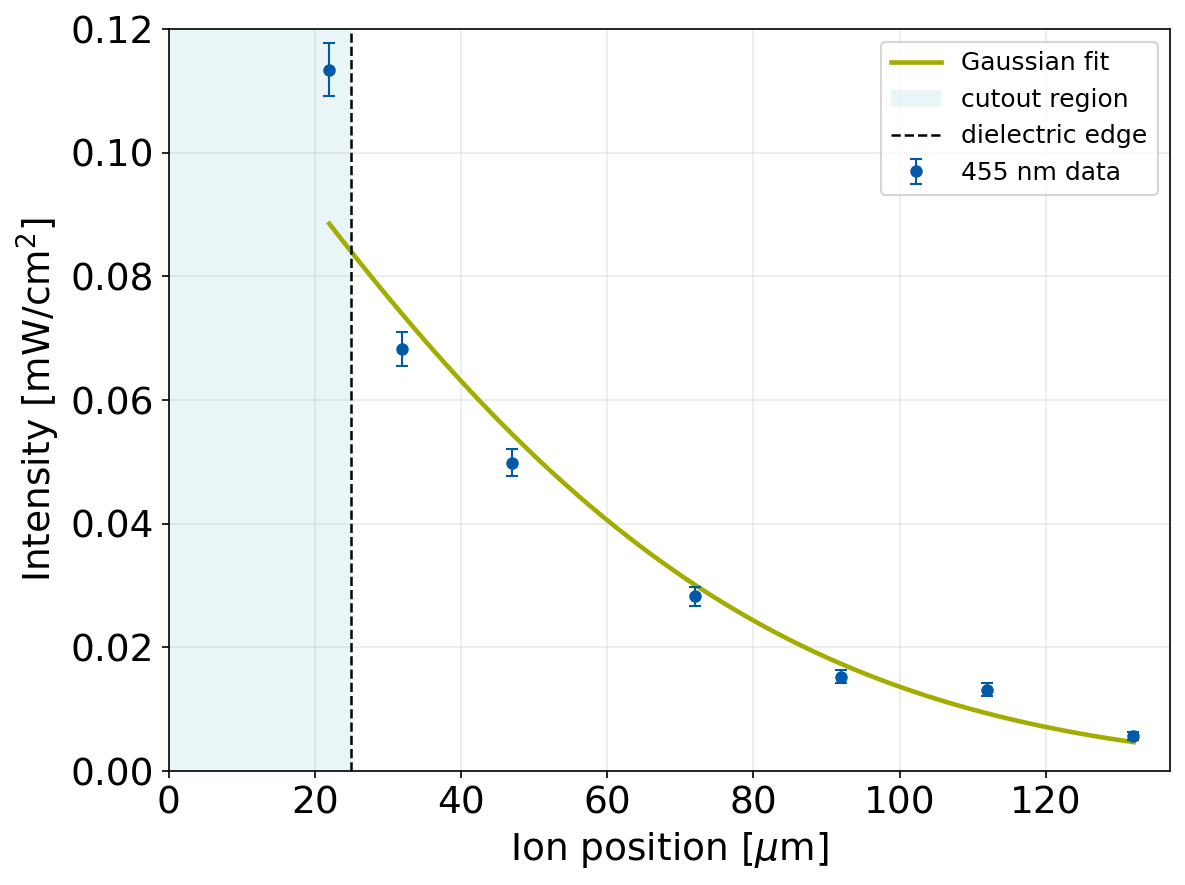

In [5]:
# -----------------------------
# Final plot: one y-axis only, intensity axis
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Positive reversed coordinate
x_fit_plot = -x_fit
x_data_plot = -disp_um

# ------------------------------------------------------------
# Shift x axis so that the dielectric/cutout edge is at +25 um
# ------------------------------------------------------------
# Before shifting, dielectric edge is at x_plot = +3 um.
# We want:
#     3 um + X_SHIFT_UM = +25 um
# so:
#     X_SHIFT_UM = +22 um
X_SHIFT_UM = 22.0

x_fit_plot_shifted = x_fit_plot + X_SHIFT_UM
x_data_plot_shifted = x_data_plot + X_SHIFT_UM

dielectric_edge_um = 3.0 + X_SHIFT_UM      # +25 um
cutout_left_um = -100.0 + X_SHIFT_UM        # +12 um

# ------------------------------------------------------------
# Plot Gaussian fit in intensity units
# ------------------------------------------------------------
ax.plot(
    x_fit_plot_shifted,
    y_fit_mW_cm2,
    color=colors["green"],
    linewidth=2.2,
    label="Gaussian fit",
)

# Cutout / dielectric region
ax.axvspan(
    cutout_left_um,
    dielectric_edge_um,
    facecolor="lightblue",
    alpha=0.25,
    edgecolor="none",
    label="cutout region",
)

# Dielectric edge at +25 um
ax.axvline(
    dielectric_edge_um,
    color="k",
    linestyle="--",
    linewidth=1.2,
    label="dielectric edge",
)

# 455 nm data in intensity units
ax.errorbar(
    x_data_plot_shifted,
    I_455_mW_cm2,
    yerr=I_455_err_mW_cm2,
    fmt="o",
    markersize=5,
    capsize=3,
    elinewidth=1,
    color=colors["blue"],
    label="455 nm data",
)

# ------------------------------------------------------------
# Axes formatting
# ------------------------------------------------------------
ax.set_xlabel(r"Ion position [$\mu$m]")
ax.set_ylabel(r"Intensity [mW/cm$^2$]")

# Previous xlim was -5 to 115.
# After shifting by +22 um, it becomes 17 to 137.
ax.set_xlim(0, 137)

# Original intensity range
ax.set_ylim(0, 0.12)

ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()

OUTPUT_PNG = "intensity_profile_dielectric_edge_25um.png"
OUTPUT_PDF = "intensity_profile_dielectric_edge_25um.pdf"

fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_PDF, bbox_inches="tight")

plt.show()

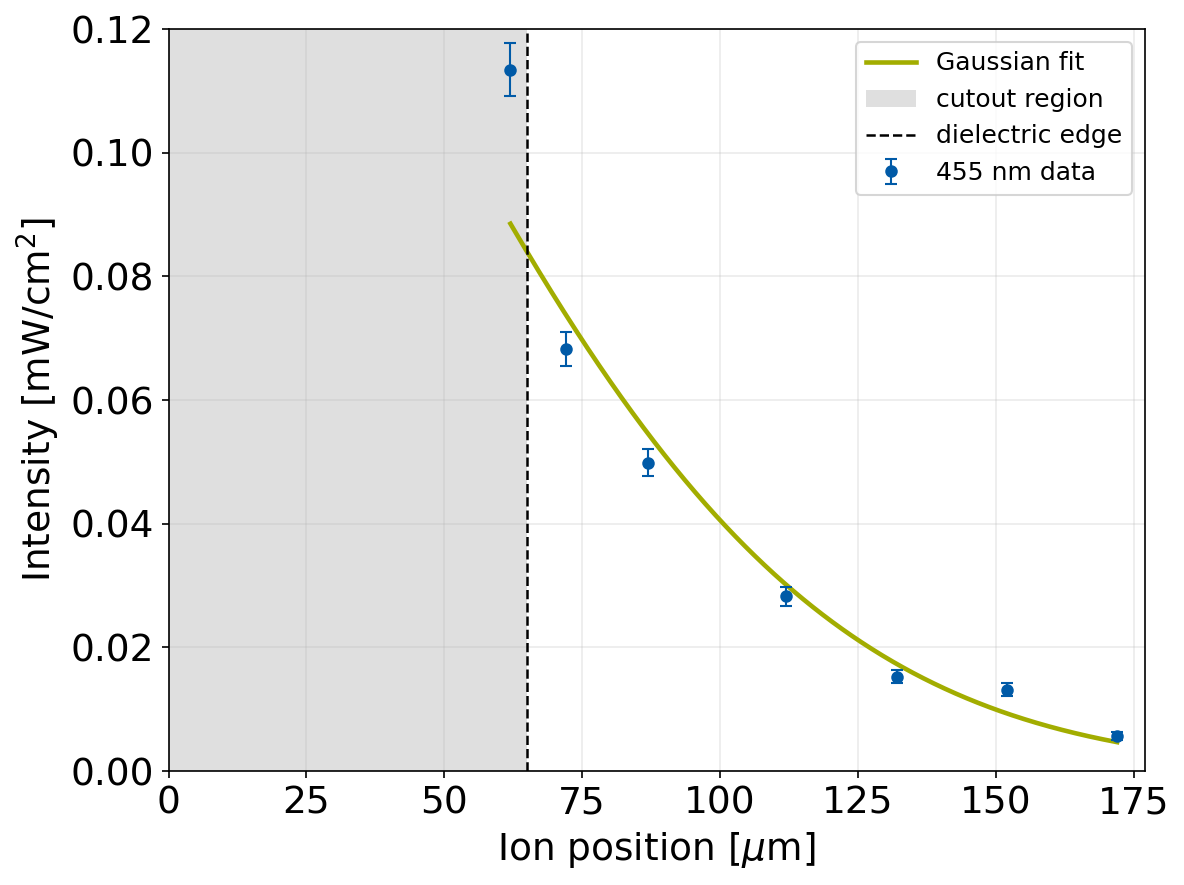

In [6]:
# -----------------------------
# Final plot: one y-axis only, intensity axis
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Positive reversed coordinate
x_fit_plot = -x_fit
x_data_plot = -disp_um

# ------------------------------------------------------------
# Shift x axis so that the dielectric/cutout edge is at +65 um
# ------------------------------------------------------------
# Before shifting, dielectric edge is at x_plot = +3 um.
# We want:
#     3 um + X_SHIFT_UM = +65 um
# so:
#     X_SHIFT_UM = +62 um
X_SHIFT_UM = 62.0

x_fit_plot_shifted = x_fit_plot + X_SHIFT_UM
x_data_plot_shifted = x_data_plot + X_SHIFT_UM

dielectric_edge_um = 3.0 + X_SHIFT_UM       # +65 um
cutout_left_um = -100.0 + X_SHIFT_UM        # -38 um

# ------------------------------------------------------------
# Plot Gaussian fit in intensity units
# ------------------------------------------------------------
ax.plot(
    x_fit_plot_shifted,
    y_fit_mW_cm2,
    color=colors["green"],
    linewidth=2.2,
    label="Gaussian fit",
)

# Cutout / dielectric region
ax.axvspan(
    cutout_left_um,
    dielectric_edge_um,
    facecolor="grey",
    alpha=0.25,
    edgecolor="none",
    label="cutout region",
)

# Dielectric edge at +65 um
ax.axvline(
    dielectric_edge_um,
    color="k",
    linestyle="--",
    linewidth=1.2,
    label="dielectric edge",
)

# 455 nm data in intensity units
ax.errorbar(
    x_data_plot_shifted,
    I_455_mW_cm2,
    yerr=I_455_err_mW_cm2,
    fmt="o",
    markersize=5,
    capsize=3,
    elinewidth=1,
    color=colors["blue"],
    label="455 nm data",
)

# ------------------------------------------------------------
# Axes formatting
# ------------------------------------------------------------
ax.set_xlabel(r"Ion position [$\mu$m]")
ax.set_ylabel(r"Intensity [mW/cm$^2$]")

# Adjust x range to keep the full shifted profile visible
ax.set_xlim(0, 177)

# Original intensity range
ax.set_ylim(0, 0.12)

ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()

OUTPUT_PNG = "intensity_profile_dielectric_edge_65um.png"
OUTPUT_PDF = "intensity_profile_dielectric_edge_65um.pdf"

fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_PDF, bbox_inches="tight")

plt.show()